In [110]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('./data/food_menu_nutrition_dataset.csv')

In [8]:
df.head()

,item_name,item_category,item_subcategory,brand_name,brand_tier,country,city,city_tier,price_usd_normalized,serving_size_g,calories,protein_g,total_fat_g,total_carbs_g,sodium_mg,sugars_g,avg_rating,is_bestseller
0,Veggie Sub,Sandwich,Veg,Five Guys,mid,UK,London,metro,8.66,224.9,438.3,23.4,27.8,46.0,744.4,12.1,4.3,0
1,Waffles with Syrup,Dessert,Veg,KFC,budget,USA,Austin,tier-2,2.78,151.7,338.5,1.3,0.0,77.3,304.5,25.8,4.4,0
2,Grilled Chicken Salad,Salad,Non-Veg,Domino's,budget,Canada,Toronto,metro,5.77,294.1,105.4,9.2,13.7,9.5,585.1,5.6,3.8,0
3,Waffles with Syrup,Dessert,Veg,Five Guys,mid,USA,Chicago,metro,8.47,87.7,404.3,5.3,7.3,79.4,461.5,58.4,4.0,0
4,Chocolate Brownie,Dessert,Veg,Subway,budget,USA,Chicago,metro,2.79,125.4,365.5,0.0,11.2,56.1,323.8,48.2,3.6,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   item_name             7500 non-null   str    
 1   item_category         7500 non-null   str    
 2   item_subcategory      7500 non-null   str    
 3   brand_name            7500 non-null   str    
 4   brand_tier            7500 non-null   str    
 5   country               7500 non-null   str    
 6   city                  7500 non-null   str    
 7   city_tier             7500 non-null   str    
 8   price_usd_normalized  7500 non-null   float64
 9   serving_size_g        7500 non-null   float64
 10  calories              7500 non-null   float64
 11  protein_g             7500 non-null   float64
 12  total_fat_g           7500 non-null   float64
 13  total_carbs_g         7500 non-null   float64
 14  sodium_mg             7500 non-null   float64
 15  sugars_g              7500 non-n

In [15]:
for col in df.columns:
    print(f'{col} has {df[col].nunique()} values')

item_name has 114 values
item_category has 8 values
item_subcategory has 3 values
brand_name has 18 values
brand_tier has 3 values
country has 5 values
city has 53 values
city_tier has 3 values
price_usd_normalized has 2147 values
serving_size_g has 3506 values
calories has 4393 values
protein_g has 416 values
total_fat_g has 451 values
total_carbs_g has 918 values
sodium_mg has 5261 values
sugars_g has 1029 values
avg_rating has 35 values
is_bestseller has 2 values


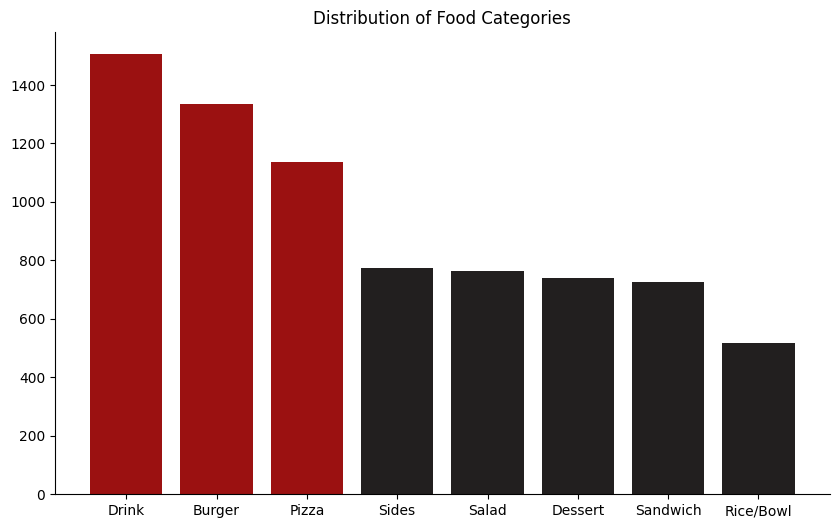

In [33]:
# View countries, item category and subcategories

food_category = df.groupby('item_category').size().sort_values(ascending=False)
cmap = ['#221f1f' for _ in food_category]
cmap[0] = cmap[1] = cmap[2] = '#9b1111'

fig, ax = plt.subplots(figsize=(10,6))
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

ax.bar(food_category.index, food_category, color=cmap)

plt.title('Distribution of Food Categories')
plt.show()

In [58]:
subcategories = df.groupby(['item_category', 'item_subcategory']).size().unstack().fillna(0).astype(int).reindex(food_category.index)
subcategories

item_subcategory,Non-Veg,Veg,Vegan
item_category,,,
Drink,0,1098,407
Burger,866,322,148
Pizza,565,454,119
Sides,120,546,109
Salad,269,357,139
Dessert,173,455,111
Sandwich,382,213,130
Rice/Bowl,281,166,70


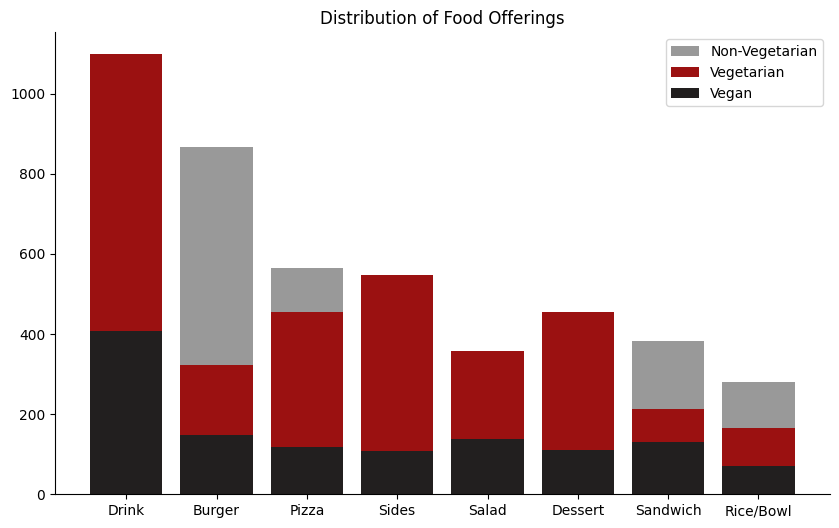

In [83]:
fig, ax = plt.subplots(figsize=(10,6))
non_veg = subcategories['Non-Veg']
veg = subcategories['Veg']
vegan = subcategories['Vegan']

ax.bar(non_veg.index, non_veg, color='#999999', label='Non-Vegetarian')
ax.bar(veg.index, veg, color='#9b1111', label='Vegetarian')
ax.bar(vegan.index, vegan, color='#221f1f', label='Vegan')

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

plt.legend()
plt.title('Distribution of Food Offerings')
plt.show()

In [88]:
by_country = np.round((df['country'].value_counts() * 100 / len(df)), 2)
by_country

country
USA          36.28
India        29.28
UK           14.04
Canada       12.01
Australia     8.39
Name: count, dtype: float64

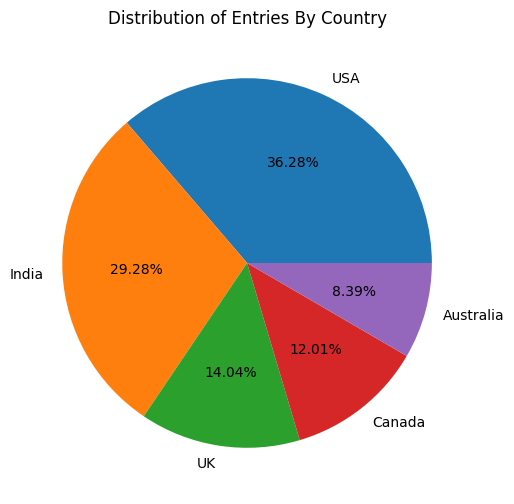

In [109]:
plt.figure(figsize=(10,6))

plt.pie(by_country, labels=by_country.index, autopct='%.2f%%')
plt.title('Distribution of Entries By Country')
plt.show()